<a href="https://colab.research.google.com/github/wtryab-re/data-preprocessing/blob/main/Numeric_Outlier_Handling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [128]:
#do this step BEFORE encoding categories

In [129]:
!pip install -q numpy pandas matplotlib seaborn scikit-learn

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [131]:
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [132]:
train = pd.read_csv("titanic_train_encoded.csv")
train.shape

(712, 19)

In [133]:
test = pd.read_csv("titanic_test_encoded.csv")
test.shape

(179, 19)

In [134]:
train.head(1)

,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_Q,embarked_S,who_man,who_woman,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,survived
0,3,1,28.5,0,0,56.4958,1,1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1


In [135]:
target_feature = "survived"

In [136]:
X_train = train.drop(target_feature, axis=1)
y_train = train[target_feature]

X_test = test.drop(target_feature, axis=1)
y_test = test[target_feature]

In [137]:
num_cols = ["sibsp", "age", "fare", "parch"]

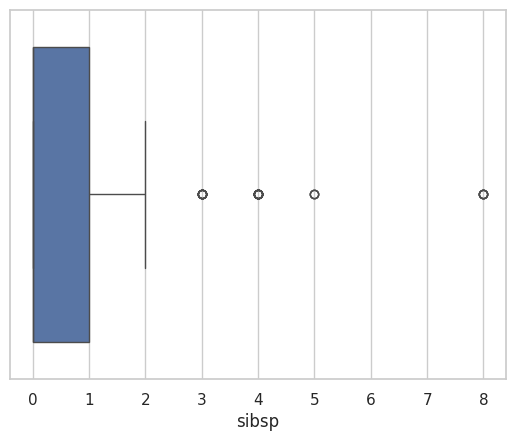

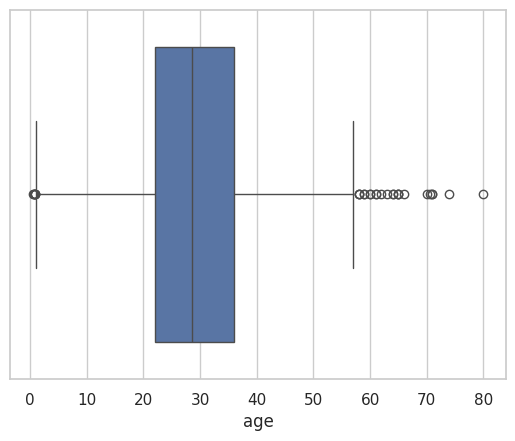

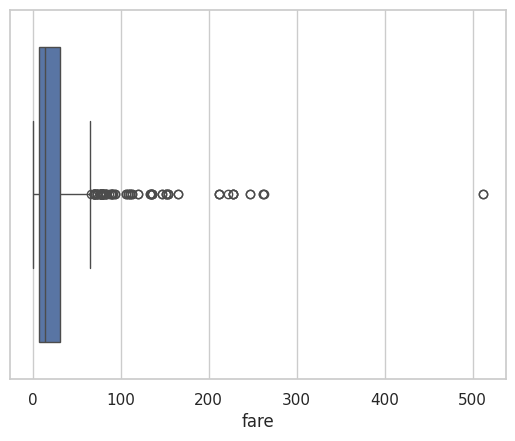

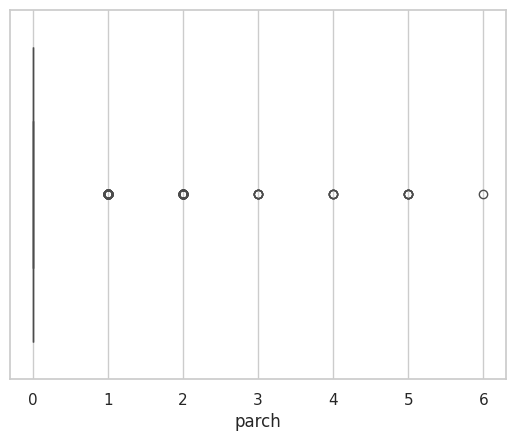

In [138]:
for col in num_cols:
  sns.boxplot(x = X_train[col])
  plt.show()
  print()

In [139]:
#we wont process the sibsp, parch as they have REALISTIC values, even the outliers, hence NO handling

In [140]:
valid_outlier_columns = ["age", "fare"]

In [141]:
#before outlier handling min and max
pd.concat([X_train[valid_outlier_columns].min(),X_train[valid_outlier_columns].max()], axis=1, keys=["min", "max"])

,min,max
age,0.42,80.0000
fare,0.00,512.3292


In [142]:
def get_bounds(df, col):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  return lower_bound, upper_bound

In [143]:
bounds = {}
for col in valid_outlier_columns:
  bounds[col] = get_bounds(X_train, col)

bounds

{'age': (np.float64(1.0), np.float64(57.0)),
 'fare': (np.float64(-26.7605), np.float64(65.6563))}

In [144]:
def IQR_outlier_capping(df, col,bounds):
  lower_bound, upper_bound =  bounds[col]
  df.loc[df[col]>upper_bound,col]=upper_bound
  df.loc[df[col]<lower_bound,col]=lower_bound
  #np.where(df[col]>upper_bound,value if true, value if false)
  #does the same thing as LOC over here
  print()
  return df

In [145]:
X_train_outlier_handled = X_train.copy()
X_test_outlier_handled = X_test.copy()

In [146]:
#capping both train and test data
for col in valid_outlier_columns:
  X_train_outlier_handled = IQR_outlier_capping(X_train_outlier_handled, col, bounds)
  X_test_outlier_handled = IQR_outlier_capping(X_test_outlier_handled, col,bounds)

In [147]:
#after outlier handling
pd.concat([X_train_outlier_handled[valid_outlier_columns].min(),X_train_outlier_handled[valid_outlier_columns].max()], axis=1, keys=["min", "max"])

,min,max
age,1.0,57.0000
fare,0.0,65.6563


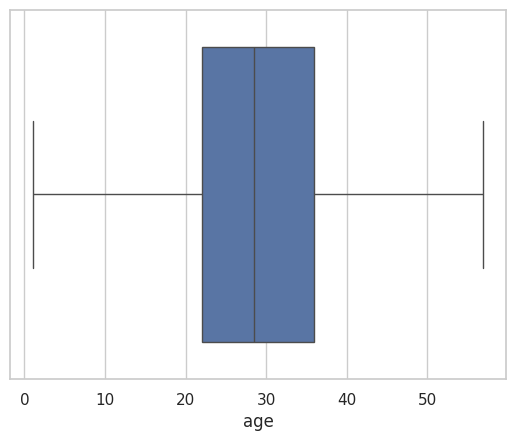

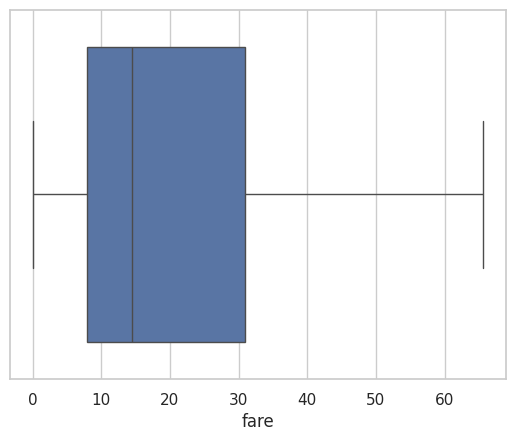

In [148]:
for col in valid_outlier_columns:
  sns.boxplot(x=X_train_outlier_handled[col])
  plt.show()
  print()

In [151]:
train_dataset = pd.concat([X_train_outlier_handled, y_train], axis=1)
test_dataset = pd.concat([X_test_outlier_handled, y_test], axis=1)

In [156]:
train_dataset.to_csv("titanic_train_outlier_handled.csv", index=False)
test_dataset.to_csv("titanic_test_outlier_handled.csv", index=False)

##Today's lessons:

1. Outliers should be handled only when they are needed, for example when they are unrealistic or continuous values

2. Capping is done instead of outright removal, where the outliers are replaced by the closest boundary

3. Linear models like svm, regressions are sensitive to outliers, so have to handle them